<a href="https://colab.research.google.com/github/KaveyaEzhil/Machine-Learning/blob/main/ML_ITA0613.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files


uploaded = files.upload()

# Read the uploaded CSV file
data = pd.read_csv("data.csv")

# Initialize hypothesis
h = []

# Find the first positive example
for i in range(len(data)):
    if data.iloc[i, -1] == "Yes":
        h = list(data.iloc[i, :-1])
        break

# Compare all positive examples
for i in range(len(data)):
    if data.iloc[i, -1] == "Yes":
        for j in range(len(h)):
            if h[j] != data.iloc[i, j]:
                h[j] = "?"

# Print the final hypothesis
print("Most specific hypothesis:")
print(h)

Saving data.csv to data.csv
Most specific hypothesis:
['Sunny', 'Warm', '?', '?']


In [ ]:
import pandas as pd
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get uploaded file name
file_name = list(uploaded.keys())[0]

# Read CSV file
data = pd.read_csv(file_name)

# Convert data into list
data = data.values.tolist()

# Number of attributes
n = len(data[0]) - 1

# Initialize S as most specific
S = ['0'] * n

# Initialize G as most general
G = [['?'] * n]

# Process each training example
for row in data:
    x = row[:-1]
    y = row[-1]

    # Positive example
    if y == "Yes":

        # Generalize S
        for i in range(n):
            if S[i] == '0':
                S[i] = x[i]
            elif S[i] != x[i]:
                S[i] = '?'

        # Remove inconsistent hypotheses from G
        G = [g for g in G if all(g[i] == '?' or g[i] == x[i] for i in range(n))]

    # Negative example
    elif y == "No":

        new_G = []

        for g in G:
            for i in range(n):
                if g[i] == '?':
                    for value in set([row[i] for row in data]):
                        if value != x[i]:
                            new_g = g.copy()
                            new_g[i] = value
                            new_G.append(new_g)

        G = new_G

# Print results
print("Final S Boundary:")
print(S)

print("\nFinal G Boundary:")
for g in G:
    print(g)

Saving data.csv to data (1).csv
Final S Boundary:
['Sunny', 'Warm', '?', '?']

Final G Boundary:
['Sunny', '?', '?', '?']
['?', 'Warm', '?', '?']
['?', '?', '?', 'Weak']


In [ ]:
import pandas as pd
import math
from google.colab import files

# Upload CSV file
uploaded = files.upload()

# Get file name
file_name = list(uploaded.keys())[0]

# Read CSV file
data = pd.read_csv(file_name)


# Function to calculate entropy
def entropy(data):
    target = data.iloc[:, -1]
    values = target.value_counts()

    e = 0

    for count in values:
        p = count / len(target)
        e = e - p * math.log2(p)

    return e


# Function to calculate information gain
def information_gain(data, attribute):
    total_entropy = entropy(data)

    values = data[attribute].unique()

    weighted_entropy = 0

    for value in values:
        subset = data[data[attribute] == value]

        weighted_entropy += (len(subset) / len(data)) * entropy(subset)

    gain = total_entropy - weighted_entropy

    return gain


# Function to build decision tree
def id3(data, attributes):

    # Get target column
    target = data.columns[-1]

    # If all values belong to one class
    if len(data[target].unique()) == 1:
        return data[target].iloc[0]

    # If no attributes are left
    if len(attributes) == 0:
        return data[target].mode()[0]

    # Find attribute with maximum information gain
    best_attribute = ""

    max_gain = -1

    for attribute in attributes:
        gain = information_gain(data, attribute)

        if gain > max_gain:
            max_gain = gain
            best_attribute = attribute

    # Create tree
    tree = {best_attribute: {}}

    # Get all values of best attribute
    values = data[best_attribute].unique()

    for value in values:

        subset = data[data[best_attribute] == value]

        remaining_attributes = attributes.copy()
        remaining_attributes.remove(best_attribute)

        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes
        )

    return tree


# Attributes except target column
attributes = list(data.columns[:-1])

# Build the decision tree
tree = id3(data, attributes)

print("Decision Tree:")
print(tree)


# Function to classify a new sample
def classify(tree, sample):

    if not isinstance(tree, dict):
        return tree

    attribute = list(tree.keys())[0]

    value = sample[attribute]

    return classify(tree[attribute][value], sample)


# Enter a new sample
sample = {}

for attribute in attributes:
    sample[attribute] = input("Enter " + attribute + ": ")

# Predict result
result = classify(tree, sample)

print("\nClassification Result:", result)

Saving data.csv to data (2).csv
Decision Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}
Enter Outlook: Sunny
Enter Temperature: Cool
Enter Humidity: High
Enter Wind: String

Classification Result: No


Accuracy: 1.0


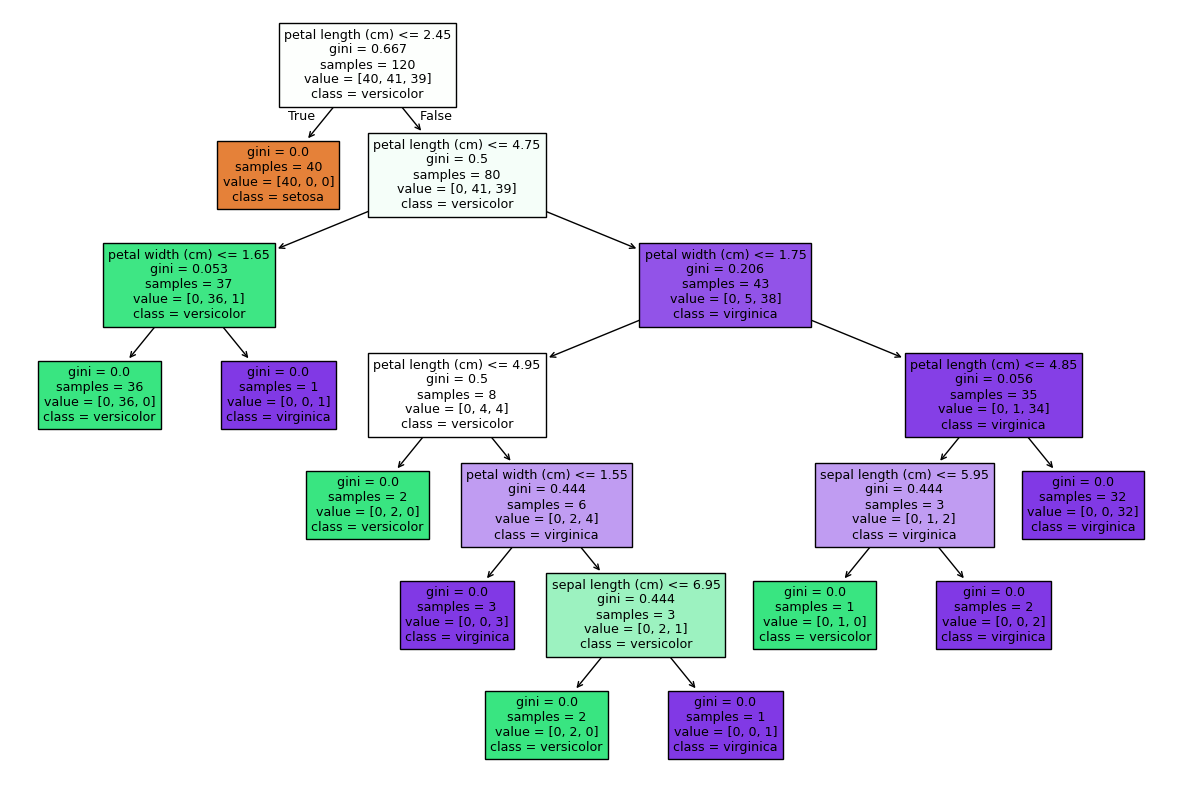

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load Iris dataset
iris = load_iris()

X = iris.data
y = iris.target

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create Decision Tree model
model = DecisionTreeClassifier()

# Train the model
model.fit(X_train, y_train)

# Predict test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

# Visualize the Decision Tree
plt.figure(figsize=(15, 10))

plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True
)

plt.show()